# Drive FSM with melt fields from a regional climate model

Load 2km downscaled RACMO snowmelt field produced as part of the workflow described in /Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/AntPen_NSF_NERC/code/rcm/cryocloud_racmosubsetting/. 

Note that the zarr this NB currently uses is only a limited time range, so an update would be to use the tools in the directory above within cryocloud to subset the data of locations of interest for the full ramco period (1979-onwards).

This NB currently applied annual melt totals from Nivlisen as a melt field to FSM. 

Another next step is to compare this to Tuckett's lake location data. 

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "/Users/jkingslake/Documents/science/meltwater_routing/fsm_pywrapper/fillspillmerge")
sys.path.insert(0, "../scripts")

from fillspillmerge import fill_spill_merge
import pdemtools as pdt
import rioxarray
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from funcs import fsm, cellArea
import dask
import hvplot.xarray


/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/notebooks/../scripts/funcs.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [63]:
snowmelt = xr.open_dataset('/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/AntPen_NSF_NERC/code/rcm/full_2km_zarr/snowmelt.zarr', engine='zarr', chunks={'x': 1000, 'y': 1000}   )

/var/folders/kl/3mt9f4qs1559xwy3mr60s7980000gp/T/ipykernel_49028/2053737042.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  snowmelt = xr.open_dataset('/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/AntPen_NSF_NERC/code/rcm/full_2km_zarr/snowmelt.zarr', engine='zarr', chunks={'x': 1000, 'y': 1000}   )
/var/folders/kl/3mt9f4qs1559xwy3mr60s7980000gp/T/ipykernel_49028/2053737042.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  snowmelt = xr.open_dataset('/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/AntPen_NSF_NERC/code/rcm/full_2km_zarr/snowmelt.zarr', engine='zarr', chunks={'x': 1000, 'y': 1000}   )


In [64]:
snowmelt

<xarray.Dataset> Size: 122GB
Dimensions:       (time: 4748, y: 2303, x: 2778)
Coordinates:
  * time          (time) datetime64[ns] 38kB 2010-01-01 ... 2022-12-31
  * x             (x) float32 11kB -2.731e+06 -2.729e+06 ... 2.821e+06 2.823e+06
  * y             (y) float32 9kB -2.232e+06 -2.23e+06 ... 2.37e+06 2.372e+06
Data variables:
    snowmeltcorr  (time, y, x) float32 122GB dask.array<chunksize=(10, 1000, 1000), meta=np.ndarray>
Attributes:
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      libUN (2013.05.22) - Sat Dec 11 10:31:43 2021
    institution:  IMAU (Brice Noel)
    netcdf:       4.7.4 of Apr 18 2020 10:56:44 $
    title:        Daily mean snowmelt field at 2km (RACMO2.3p2) ERA

In [65]:
snowmelt.rio.write_crs("EPSG:3031", inplace=True)
snowmelt

<xarray.Dataset> Size: 122GB
Dimensions:       (time: 4748, y: 2303, x: 2778)
Coordinates:
  * time          (time) datetime64[ns] 38kB 2010-01-01 ... 2022-12-31
  * x             (x) float32 11kB -2.731e+06 -2.729e+06 ... 2.821e+06 2.823e+06
  * y             (y) float32 9kB -2.232e+06 -2.23e+06 ... 2.37e+06 2.372e+06
    spatial_ref   int64 8B 0
Data variables:
    snowmeltcorr  (time, y, x) float32 122GB dask.array<chunksize=(10, 1000, 1000), meta=np.ndarray>
Attributes:
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      libUN (2013.05.22) - Sat Dec 11 10:31:43 2021
    institution:  IMAU (Brice Noel)
    netcdf:       4.7.4 of Apr 18 2020 10:56:44 $
    title:        Daily mean snowmelt field at 2km (RACMO2.3p2) ERA

In [66]:
d = rioxarray.open_rasterio('Nivlisen_32m_REMA.tif').squeeze()
coarsen_factor = 2
d = d.coarsen(x=coarsen_factor, y=coarsen_factor, boundary='trim').mean()
ocean_value = 0.0

d[0:1,:] = ocean_value 
d[-1:,:] = ocean_value
d[:,0:1] = ocean_value
d[:,-1:] = ocean_value

_, dh = fill_spill_merge(
    topography=d,
    ocean_level=0.0,
    return_hierarchy=True,
)

In [67]:
bounds = d.rio.bounds()

In [68]:
nivlisen_melt = snowmelt.snowmeltcorr.rio.clip_box(*bounds)

In [69]:
nivlisen_melt.nbytes/1e6

38.249888

In [70]:
import sliderule

# Restore original getaddrinfo
import socket
import _socket
socket.getaddrinfo = _socket.getaddrinfo

from dask.distributed import Client
client = Client()

2026-08-26 03:39:16,990 - distributed.scheduler - WARNING - Worker failed to heartbeat for 901s; attempting restart: <WorkerState 'tcp://127.0.0.1:62661', name: 1, status: running, memory: 0, processing: 0>
2026-08-26 03:39:17,008 - distributed.scheduler - WARNING - Worker failed to heartbeat for 901s; attempting restart: <WorkerState 'tcp://127.0.0.1:62662', name: 0, status: running, memory: 0, processing: 0>
2026-08-26 03:39:17,009 - distributed.scheduler - WARNING - Worker failed to heartbeat for 901s; attempting restart: <WorkerState 'tcp://127.0.0.1:62663', name: 3, status: running, memory: 0, processing: 0>
2026-08-26 03:39:17,009 - distributed.scheduler - WARNING - Worker failed to heartbeat for 901s; attempting restart: <WorkerState 'tcp://127.0.0.1:62664', name: 2, status: running, memory: 0, processing: 0>
2026-08-26 03:39:17,660 - distributed.nanny - WARNING - Restarting worker
2026-08-26 03:39:17,665 - distributed.nanny - WARNING - Restarting worker
2026-08-26 03:39:17,785 

In [71]:
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 24.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:62650,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:62662,Total threads: 2
Dashboard: http://127.0.0.1:62665/status,Memory: 6.00 GiB
Nanny: tcp://127.0.0.1:62653,


In [41]:
nivlisen_melt.compute()

<xarray.DataArray 'snowmeltcorr' (time: 4748, y: 38, x: 53)> Size: 38MB
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.66798407, 0.70111793, 0.7274721 , ..., 0.7237069 ,
         0.65059274, 0.6228357 ],
        [0.64543414, 0.6869616 , 0.71551204, ..., 0.75583977,
         0.84733593, 0.8306821 ],
        [0.62256014, 0.6681905 , 0.70397836, ..., 0.7933054 ,
         0.927153  , 0.93295825]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.4507206 , 0.3711031 , 0.28428024, ..., 0.11218858,
         0.01952803, 0.        ],
        [0.40072447, 0.33882117, 0.2597574 , ..., 0.12251836,
         0.1352047 , 0.07832864],
        [0.34911138, 0.2951296 , 0.23559237, ..., 0.13044888,
         0.17842677, 0.14440566]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.7053407 , 0.5929905 , 0.47016835, ..., 0.17645425,
         0.04110312, 0.        ],
        [0.628919  , 0.5416864 , 0.42961657, ..., 0.24048913,
         0.24377346, 0.1458109 ],
        [0.55042607, 0.474059  , 0.389656  , ..., 0.24464554,
         0.28808385, 0.21503681]]], shape=(4748, 38, 53), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 38kB 2010-01-01 2010-01-02 ... 2022-12-31
  * x            (x) float32 212B 3.85e+05 3.87e+05 ... 4.87e+05 4.89e+05
  * y            (y) float32 152B 2.042e+06 2.044e+06 ... 2.114e+06 2.116e+06
    spatial_ref  int64 8B 0
Attributes:
    actual_range:   [0.0, 19.795740127563477]
    grid:           Map Projection: Antarctic Polar Stereographic EPSG3031 - ...
    history:        libUN (2013.05.22) - Sat Dec 11 10:31:43 2021
    institution:    IMAU (Brice Noel)
    long_name:      Downscaled 2km snowmelt
    netcdf:         4.7.4 of Apr 18 2020 10:56:44 $
    standard_name:  Downscaled_2km_snowmelt
    title:          Daily mean snowmelt field at 2km (RACMO2.3p2) ERA
    units:          mm w.e. per day

In [43]:
nivlisen_melt.to_netcdf('nivlisen_2km_snowmelt.nc')

In [4]:
m_all = xr.open_dataset('nivlisen_2km_snowmelt.nc')
m_all.load()

<xarray.Dataset> Size: 38MB
Dimensions:       (time: 4748, x: 53, y: 38)
Coordinates:
  * time          (time) datetime64[ns] 38kB 2010-01-01 ... 2022-12-31
  * x             (x) float32 212B 3.85e+05 3.87e+05 ... 4.87e+05 4.89e+05
  * y             (y) float32 152B 2.042e+06 2.044e+06 ... 2.114e+06 2.116e+06
Data variables:
    spatial_ref   int64 8B 0
    snowmeltcorr  (time, y, x) float32 38MB 0.0 0.0 0.0 ... 0.2446 0.2881 0.215

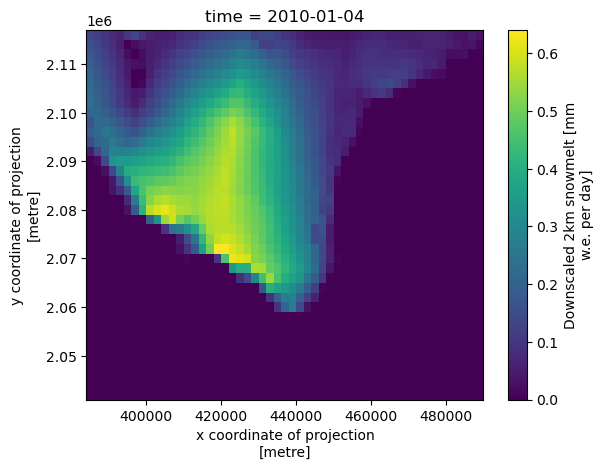

In [5]:
m_all.isel(time=3).snowmeltcorr.plot()

In [72]:
m_i = nivlisen_melt.interp_like(d)

In [77]:
m_i.nbytes/1e9

35.605650832

In [ ]:
m_i.shape


AttributeError: 'DataArray' object has no attribute 'snowmeltcorr'

In [78]:
# --- Total for each austral year ---
annual_total = m_i.resample(time='YS-JUL').sum()
# labels each group by the July 1 that starts it, e.g. label "2000-07-01"
# covers Jul 2000 – Jun 2001

# --- Cumulative sum, resetting every June 30 ---
# cumsum = m_i.snowmeltcorr.resample(time='YS-JUL').map(lambda x: x.cumsum('time'))

In [79]:
annual_total

<xarray.DataArray 'snowmeltcorr' (time: 14, y: 1171, x: 1601)> Size: 105MB
dask.array<stack, shape=(14, 1171, 1601), dtype=float32, chunksize=(1, 1171, 1601), chunktype=numpy.ndarray>
Coordinates:
    spatial_ref  int64 8B 0
  * x            (x) float64 13kB 3.858e+05 3.859e+05 ... 4.881e+05 4.882e+05
  * y            (y) float64 9kB 2.117e+06 2.116e+06 ... 2.042e+06 2.042e+06
  * time         (time) datetime64[ns] 112B 2009-07-01 2010-07-01 ... 2022-07-01
Attributes:
    actual_range:   [0.0, 19.795740127563477]
    grid:           Map Projection: Antarctic Polar Stereographic EPSG3031 - ...
    history:        libUN (2013.05.22) - Sat Dec 11 10:31:43 2021
    institution:    IMAU (Brice Noel)
    long_name:      Downscaled 2km snowmelt
    netcdf:         4.7.4 of Apr 18 2020 10:56:44 $
    standard_name:  Downscaled_2km_snowmelt
    title:          Daily mean snowmelt field at 2km (RACMO2.3p2) ERA
    units:          mm w.e. per day

In [80]:
annual_total.load()

<xarray.DataArray 'snowmeltcorr' (time: 14, y: 1171, x: 1601)> Size: 105MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(14, 1171, 1601), dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
  * x            (x) float64 13kB 3.858e+05 3.859e+05 ... 4.881e+05 4.882e+05
  * y            (y) float64 9kB 2.117e+06 2.116e+06 ... 2.042e+06 2.042e+06
  * time         (time) datetime64[ns] 112B 2009-07-01 2010-07-01 ... 2022-07-01
Attributes:
    actual_range:   [0.0, 19.795740127563477]
    grid:           Map Projection: Antarctic Polar Stereographic EPSG3031 - ...
    history:        libUN (2013.05.22) - Sat Dec 11 10:31:43 2021
    institution:    IMAU (Brice Noel)
    long_name:      Downscaled 2km snowmelt
    netcdf:         4.7.4 of Apr 18 2020 10:56:44 $
    standard_name:  Downscaled_2km_snowmelt
    title:          Daily mean snowmelt field at 2km (RACMO2.3p2) ERA
    units:          mm w.e. per day

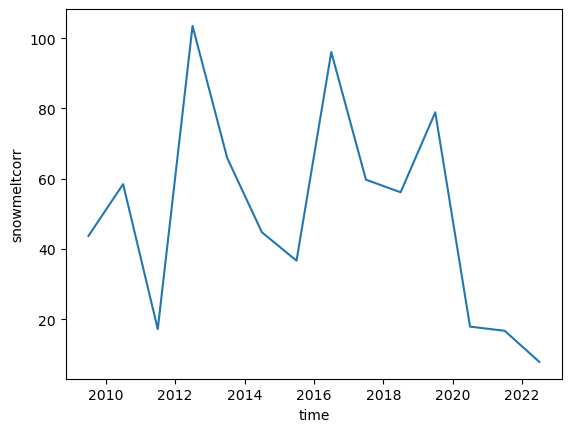

In [14]:
annual_total.mean(dim=['x', 'y']).plot()

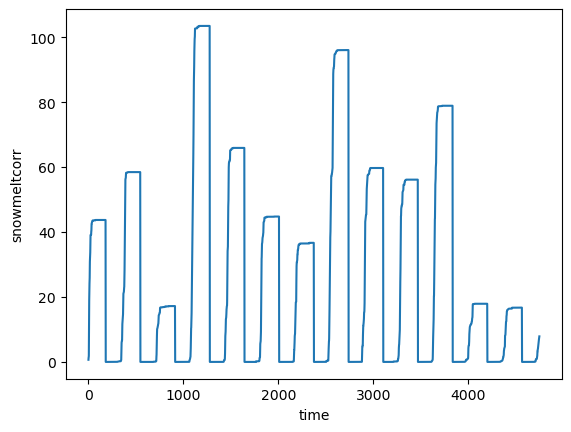

In [16]:
cumsum.mean(dim=['x', 'y']).plot()

In [81]:
# cumsum.to_zarr('nivlisen_2km_snowmelt_cumsum.zarr', mode='w', consolidated=True)
annual_total.to_zarr('nivlisen_2km_snowmelt_annual_total_higher_res.zarr', mode='w', consolidated=True)

In [82]:
annual_total = xr.open_zarr('nivlisen_2km_snowmelt_annual_total_higher_res.zarr', consolidated=True)
# cumsum = xr.open_zarr('nivlisen_2km_snowmelt_cumsum.zarr', consolidated=True)

In [84]:
annual_total

<xarray.Dataset> Size: 105MB
Dimensions:       (time: 14, y: 1171, x: 1601)
Coordinates:
    spatial_ref   int64 8B ...
  * time          (time) datetime64[ns] 112B 2009-07-01 ... 2022-07-01
  * x             (x) float64 13kB 3.858e+05 3.859e+05 ... 4.881e+05 4.882e+05
  * y             (y) float64 9kB 2.117e+06 2.116e+06 ... 2.042e+06 2.042e+06
Data variables:
    snowmeltcorr  (time, y, x) float32 105MB dask.array<chunksize=(2, 293, 401), meta=np.ndarray>

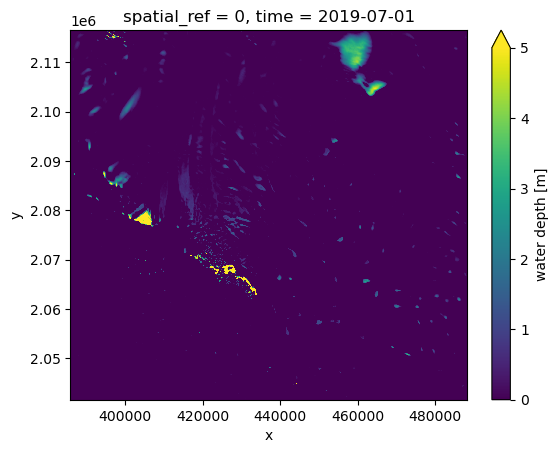

In [85]:
fsm(d,annual_total.snowmeltcorr.isel(time=10)/1000, dh = dh).water_depth.plot(vmax = 5)

In [86]:
results = []
for t in annual_total.time:
    r = fsm(d, annual_total.snowmeltcorr.sel(time=t) / 1000, dh=dh)
    results.append(r)

ds = xr.concat(results, dim=annual_total.time)

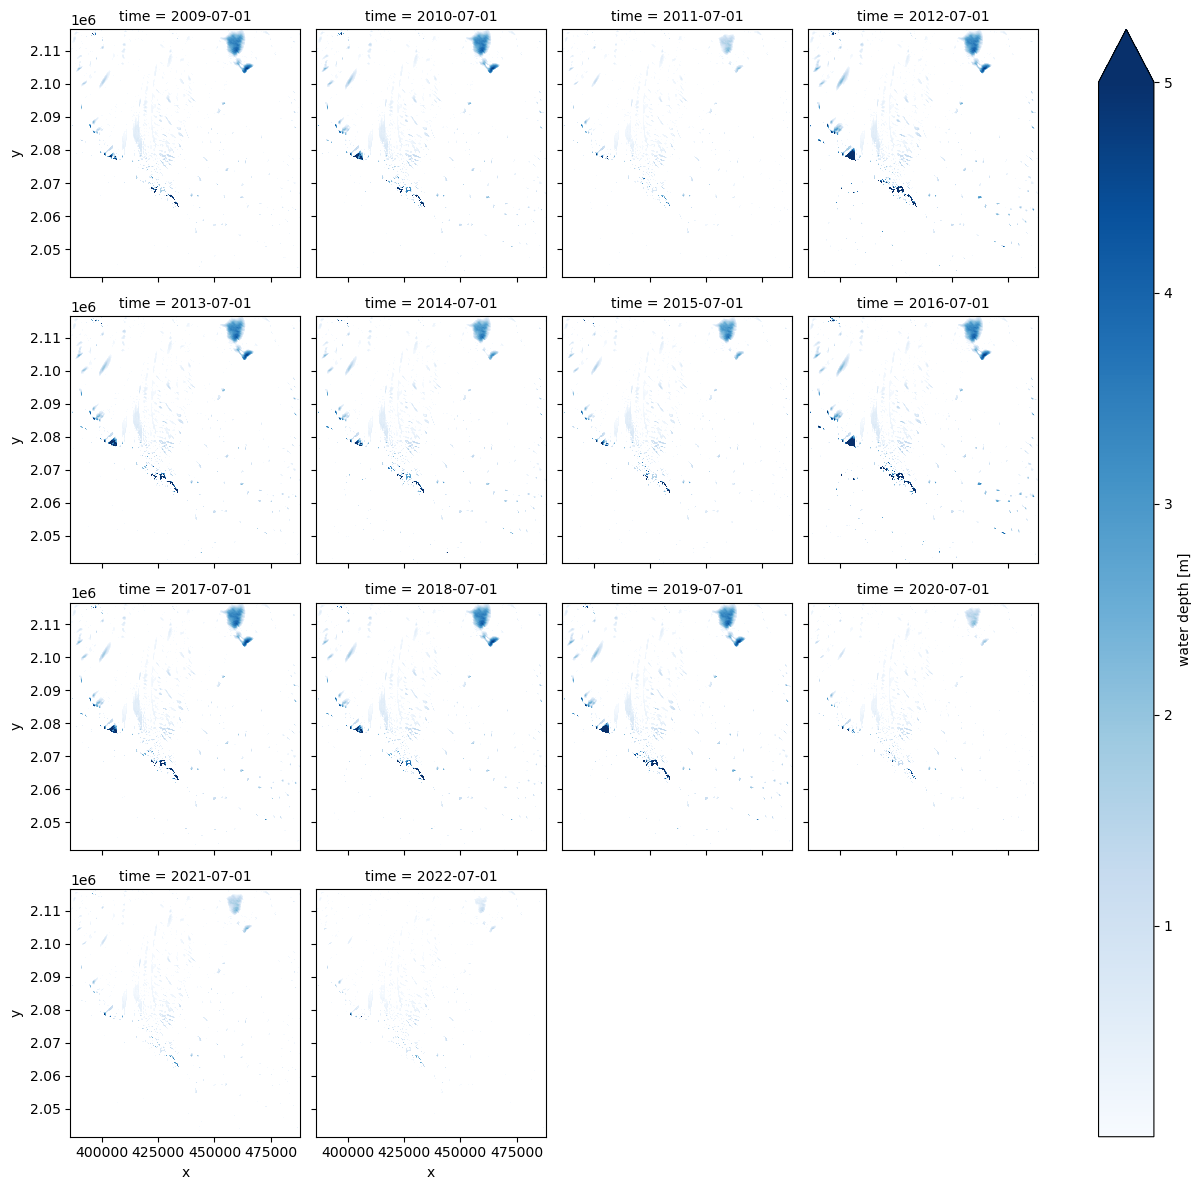

In [87]:
ds.water_depth.where(ds.water_depth > 0).plot(x='x', y = 'y', col = 'time', col_wrap = 4, cmap = 'Blues', vmax = 5)

In [21]:
ds

<xarray.Dataset> Size: 50MB
Dimensions:                       (time: 14, y: 234, x: 320)
Coordinates:
  * time                          (time) datetime64[ns] 112B 2009-07-01 ... 2...
  * x                             (x) float64 3kB 3.859e+05 ... 4.88e+05
  * y                             (y) float64 2kB 2.116e+06 ... 2.042e+06
    spatial_ref                   int64 8B 0
Data variables: (12/17)
    water_depth                   (time, y, x) float64 8MB 0.0 0.0 ... 0.0 0.0
    melt                          (time, y, x) float64 8MB dask.array<chunksize=(1, 117, 160), meta=np.ndarray>
    x_com_w                       (time) float64 112B 4.352e+05 ... 4.292e+05
    y_com_w                       (time) float64 112B 2.092e+06 ... 2.086e+06
    x_com_m                       (time) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    y_com_m                       (time) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                            ...
    water_flow_over_GL            (time) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    grounded_mask                 (time, y, x) int64 8MB 0 0 0 0 0 ... 1 1 1 1 1
    accumulation_total            (time) float64 112B 2.689e+08 ... 5.861e+07
    melt_total                    (time) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    flow_direction                (time, y, x) float64 8MB nan nan ... nan nan
    flow_accumulation             (time, y, x) float64 8MB nan nan ... nan nan
Attributes:
    fillspillmerge_ocean_level:            0.0
    fillspillmerge_used_cached_hierarchy:  True
    long_name:                             water depth
    units:                                 m

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
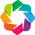

BokehModel(combine_events=True, render_bundle={'docs_json': {'22640bc3-c65c-45e1-b7fb-4763850d2004': {'version…

:DynamicMap   [time]
   :Overlay
      .Image.I                 :Image   [x,y]   (value)
      .Image.II                :Image   [x,y]   (water depth)
      .Scatter.COM_of_melt     :Scatter   [x_com_m]   (melt center of mass y coord)
      .Scatter.COM_of_water    :Scatter   [x_com_w]   (water center of mass y coord)
      .Contours.Grounding_line :Contours   [x,y]   (grounded ice mask)

In [91]:
hv.extension('bokeh')
d.hvplot(x='x', y='y', cmap='gist_earth', width = 1000, height = 600)\
    *ds.water_depth.where(ds.water_depth > 0).hvplot(x='x', y = 'y', clim = (0,5), cmap = 'Blues', colorbar = True)\
        * ds[['x_com_m', 'y_com_m']].hvplot.scatter(x = 'x_com_m', y = 'y_com_m', color = 'red', size = 500, marker = 'o', label = 'COM of melt')\
        * ds[['x_com_w', 'y_com_w']].hvplot.scatter(x = 'x_com_w', y = 'y_com_w', color = 'green', size = 500, marker = 'o', label = 'COM of water')\
        * ds.grounded_mask.hvplot.contour(x='x', y='y', alpha = 0.5, color = 'black', label = 'Grounding line')

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 14.38 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 14.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


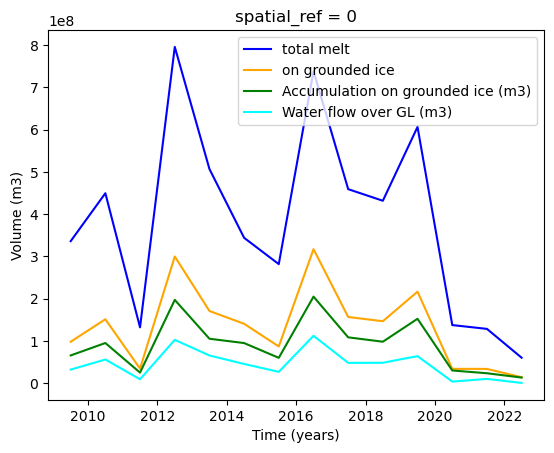

In [88]:

%matplotlib inline
ds.melt_total.plot(label = 'total melt' , color = 'blue')
ds.melt_on_grounded_ice.plot(label = 'on grounded ice', color = 'orange')
ds.accumulation_on_grounded_ice.plot(label = 'Accumulation on grounded ice (m3)', color = 'green')
ds.water_flow_over_GL.plot(label = 'Water flow over GL (m3)', color = 'cyan')
plt.xlabel('Time (years)')
plt.ylabel('Volume (m3)')
plt.legend()

/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 214.68 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


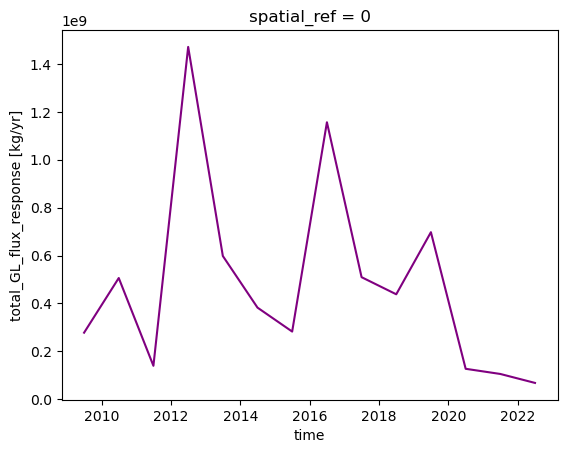

In [89]:
ds.total_GL_flux_response.plot(label = 'Total GL flux response (kg/year)', color = 'purple')


/Users/jkingslake/.local/share/mamba/envs/pdem_tools/lib/python3.13/site-packages/distributed/client.py:3357: UserWarning: Sending large graph of size 14.39 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


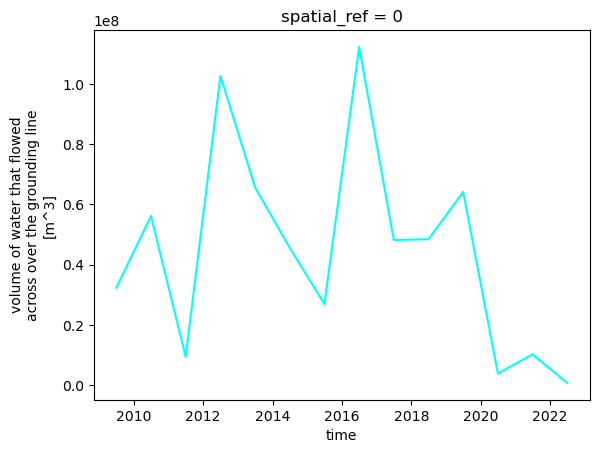

In [90]:
ds.water_flow_over_GL.plot(label = 'Water flow over GL (m3)', color = 'cyan')


In [42]:
import hvplot
import holoviews as hv

# hvplot.extension('matplotlib')

plot = (
    d.hvplot(x='x', y='y', cmap='gist_earth', width=1000, height=600, dynamic=False)
    * ds.water_depth.where(ds.water_depth > 0).hvplot(x='x', y='y', clim=(0, 5), cmap='Blues', colorbar=True, dynamic=False)
    * ds[['x_com_m', 'y_com_m']].hvplot.scatter(x='x_com_m', y='y_com_m', color='red', size=500, marker='o', label='COM of melt', dynamic=False)
    * ds[['x_com_w', 'y_com_w']].hvplot.scatter(x='x_com_w', y='y_com_w', color='green', size=500, marker='o', label='COM of water', dynamic=False)
    * ds.grounded_mask.hvplot.contour(x='x', y='y', alpha=0.5, color='black', label='Grounding line', dynamic=False)
)

hv.save(plot, 'melt_animation2.gif', fmt='gif', backend='matplotlib', fps=2)